# NSS 网格校准与单张热力图

本单元在训练期网格评估两个 NSS 衰减参数，逐点调用 [c02 的固定 λ 拟合](c02_NSSFitting.ipynb)，不复制拟合算法。网格上下限及步长分别作为参数；只拟合满足 `0 < lambda2 < lambda1` 的组合。输入为 [c01](c01_TermStructureInputs.ipynb) 的合约期限长表，终点为合约最后有效日自然日末（上海时区次日 00:00），尺度保持上游原值。

训练期选择 λ，测试期固定 λ 并逐点重新估计 β；测试价格和期限不参与网格误差、投票或权重计算。三个选择方法并列返回，不自动互相替代：

- `min_error`：最小化调用者指定的训练期目标；默认累计 SSE，即 \(\min_{\lambda}\sum_s\min_{\beta_s}\sum_i(y_{si}-X_i(\lambda)\beta_s)^2\)。固定 λ 后求 β，再比较 λ，是可分离最小二乘的网格实现。网格只能保证候选集合内最小，不能宣称连续域全局最优。[Banholzer、Fliege、Werner (2024)](https://www.tandfonline.com/doi/abs/10.1080/02331934.2024.2389242)讨论该类分离结构及病态性。
- `legacy_frequency`：逐训练点找最小 MSE 组合，统计胜出次数，取次数最多者。单点平票、总次数平票均取 `grid_id` 最小者，保持确定的网格顺序。
- `legacy_error_weighted`：令 \(e_g\) 为网格在训练点上的平均 MSE，\(\sigma\) 为这些平均误差的样本标准差（`ddof=1`），\(p=\text{weight_power}>0\)。取 \(w_g\propto\exp[-(e_g/\sigma)^p]\)，再取 \(\lambda_j=\exp(\sum_gw_g\log\lambda_{jg})\)。保留指数权重及 log λ 几何平均定义，不吸附回某个网格。`weight_power` 默认 3，可显式指定；旧实验中的 23 是一项配置。

后两项的定义依据只读旧实现 `05_Old_Projects/old_02_Feature_Engineering/b03_curve_structure_NSS_02_beta.ipynb` 的 `compute_optimal_lambda_by_frequency`、`compute_log_weighted_lambda`；这里只迁移公式，不执行归档代码。全等误差或仅一个候选时，权重定义为均匀；其余情形平移 log 权重计算，防止全部指数下溢。这些边界扩展在说明及测试中单独核查。

对外函数为 `build_nss_grid`、`evaluate_nss_grid`、`summarize_nss_grid`、`select_nss_lambdas` 和 `plot_nss_calibration_heatmap`。前三项计算网格及训练诊断，第四项只选择 λ，第五项只消费已有汇总表，每次返回一张图。执行与产物归属见 [研究规则](../../AGENTS.md) 和 [研究说明](../../README.md#期限结构输入)。

In [18]:
from pathlib import Path
import sys
project_markers = [".git", ".env", "config/settings.py"]
current_path = Path.cwd().resolve()
for candidate_root in [current_path, *current_path.parents]:
    if all((candidate_root / marker).exists() for marker in project_markers):
        sys.path.insert(0, str(candidate_root))
        sys.path.insert(0, str(candidate_root / "04_Research"))
        break
else:
    raise RuntimeError("未找到项目根目录")


In [19]:
from __future__ import annotations
from decimal import Decimal, ROUND_FLOOR
import numpy as np
import pandas as pd
import pyarrow as pa
from config.data_contracts import pandas_to_arrow, arrow_to_pandas
from a01_Methods.b05_TermStructureModeling.c01_TermStructureInputs import (
    TERM_STRUCTURE_INPUT_SCHEMA, TERM_STRUCTURE_TIMEZONE, TERM_STRUCTURE_TERMINAL_RULE,
    SAMPLING_POSITION_SCHEMA, iter_term_structure_curves,
)
from a01_Methods.b05_TermStructureModeling.c02_NSSFitting import (
    NSS_COEFFICIENT_SCHEMA, NSS_FITTED_SCHEMA, NSS_COEFFICIENT_NAMES, NSS_COLUMN_LABELS,
    fit_nss_curve, fit_nss_sequence,
)

NSS_CALIBRATION_VERSION = "0.1.0"
NSS_SELECTION_METHODS = ("min_error", "legacy_frequency", "legacy_error_weighted")
NSS_CALIBRATION_METADATA = {b"method_name": b"nss_calibration", b"method_version": NSS_CALIBRATION_VERSION.encode(),
    b"terminal_rule": TERM_STRUCTURE_TERMINAL_RULE.encode(), b"calibration_side": b"train",
    b"lambda_unit": b"inverse natural day", b"lambda_relation": b"0 < lambda2 < lambda1",
    b"comparison_policy": b"common successful training points across all admissible candidates"}
NSS_GRID_SCHEMA = pa.schema([
    pa.field("grid_id", pa.int64(), nullable=False),
    *[pa.field(name, pa.int64(), nullable=False) for name in ("lambda1_index", "lambda2_index")],
    *[pa.field(name, pa.float64(), nullable=False) for name in ("lambda1", "lambda2")],
    pa.field("grid_status", pa.string(), nullable=False), pa.field("grid_reason", pa.string(), nullable=False),
], metadata={**NSS_CALIBRATION_METADATA, b"primary_key": b"grid_id", b"grid_scale": b"linear additive steps"})
NSS_GRID_FITS_SCHEMA = pa.schema([pa.field("grid_id", pa.int64(), nullable=False), *NSS_COEFFICIENT_SCHEMA],
    metadata={**NSS_CALIBRATION_METADATA, b"primary_key": b"grid_id,sample_id"})
NSS_GRID_SUMMARY_SCHEMA = pa.schema([
    *NSS_GRID_SCHEMA,
    *[pa.field(name, pa.int64(), nullable=False) for name in (
        "training_point_count", "success_count", "failure_count", "comparison_point_count", "winner_count")],
    *[pa.field(name, pa.float64()) for name in ("objective_value", "mean_mse", "error_weight")],
    *[pa.field(name, pa.string(), nullable=False) for name in ("error_metric", "error_aggregation", "summary_status", "summary_reason")],
], metadata={**NSS_CALIBRATION_METADATA, b"primary_key": b"grid_id"})
NSS_SELECTION_SCHEMA = pa.schema([
    pa.field("selection_method", pa.string(), nullable=False), pa.field("selected_grid_id", pa.int64()),
    *[pa.field(name, pa.float64()) for name in ("lambda1", "lambda2", "objective_value")],
    pa.field("comparison_point_count", pa.int64(), nullable=False), pa.field("weight_power", pa.float64(), nullable=False),
    *[pa.field(name, pa.string(), nullable=False) for name in ("selection_status", "selection_reason")],
], metadata={**NSS_CALIBRATION_METADATA, b"primary_key": b"selection_method"})
NSS_SELECTED_COEFFICIENT_SCHEMA = pa.schema([
    pa.field("selection_method", pa.string(), nullable=False), *NSS_COEFFICIENT_SCHEMA],
    metadata={**NSS_CALIBRATION_METADATA, b"primary_key": b"selection_method,sample_id"})
NSS_SELECTED_FITTED_SCHEMA = pa.schema([
    pa.field("selection_method", pa.string(), nullable=False), *NSS_FITTED_SCHEMA],
    metadata={**NSS_CALIBRATION_METADATA, b"primary_key": b"selection_method,sample_id,contract_code"})


## 网格与训练期逐点拟合

`build_nss_grid` 的两个坐标各由 `min`、`max`、`step` 定义。下限包含；上限包含的前提是能以完整步长到达，否则最后一个节点低于上限，不追加变宽节点。十进制步长避免二进制浮点累计误差。网格行按 λ₁、λ₂ 递增确定 `grid_id`；不满足大小关系的行保留 `excluded`，不送入求解，也不伪造误差。

`evaluate_nss_grid` 在 `sample_side == 'train'` 的点上调用 c02 单曲线函数，保留每一有效网格与每一训练点的系数、误差、识别诊断及失败原因。调用者给定系数约束、停止容差及迭代上限；不设置最低合约数量、不改变失败参数重试。空训练集保留空结果，后续选择记录失败。

In [20]:
def build_nss_grid(*, lambda1_min: float, lambda1_max: float, lambda1_step: float,
                   lambda2_min: float, lambda2_max: float, lambda2_step: float) -> pd.DataFrame:
    '''独立线性坐标；上限只有能按完整步长到达时才成为节点。'''
    axes = []
    for lower, upper, step in ((lambda1_min, lambda1_max, lambda1_step), (lambda2_min, lambda2_max, lambda2_step)):
        if any(isinstance(value, (bool, np.bool_)) or not np.isfinite(float(value)) for value in (lower, upper, step)):
            raise ValueError("网格上下限及步长必须为有限实数")
        lower, upper, step = map(lambda value: Decimal(str(value)), (lower, upper, step))
        if lower <= 0 or upper < lower or step <= 0:
            raise ValueError("网格下限和步长必须为正，上限不得低于下限")
        count = int(((upper-lower)/step).to_integral_value(rounding=ROUND_FLOOR)) + 1
        coordinates = [float(lower + i*step) for i in range(count)]
        if len(set(coordinates)) != len(coordinates):
            raise ValueError("网格步长小于 float64 可区分精度")
        axes.append(coordinates)
    rows = []
    for i, lambda1 in enumerate(axes[0]):
        for j, lambda2 in enumerate(axes[1]):
            admissible = lambda2 < lambda1
            rows.append(dict(grid_id=len(rows), lambda1_index=i, lambda2_index=j,
                lambda1=lambda1, lambda2=lambda2, grid_status="ok" if admissible else "excluded",
                grid_reason="" if admissible else "lambda_order_violation"))
    return arrow_to_pandas(pandas_to_arrow(pd.DataFrame(rows), NSS_GRID_SCHEMA), NSS_GRID_SCHEMA)


def evaluate_nss_grid(term_structure_df: pd.DataFrame | pa.Table, grid_df: pd.DataFrame, *,
                      coefficient_constraints: dict | None = None, solver_tol: float = 1e-10,
                      max_iter: int = 100, constraint_tolerance: float = 1e-8, progress_callback=None) -> pd.DataFrame:
    '''只拟合训练期的合法网格，逐点保留失败和识别诊断。'''
    candidates = grid_df.loc[grid_df["grid_status"].eq("ok")].sort_values("grid_id")
    if candidates["grid_id"].duplicated().any():
        raise ValueError("grid_id 必须唯一")
    for candidate in candidates.itertuples(index=False):
        fit_nss_curve([], [], lambda1=candidate.lambda1, lambda2=candidate.lambda2,
            coefficient_constraints=coefficient_constraints, solver_tol=solver_tol,
            max_iter=max_iter, constraint_tolerance=constraint_tolerance)
    inputs_df = term_structure_df.to_pandas() if isinstance(term_structure_df, pa.Table) else term_structure_df
    training_df = inputs_df.loc[inputs_df["sample_side"].eq("train")]
    total = training_df["sample_id"].nunique() * len(candidates)
    rows = []
    for curve in iter_term_structure_curves(training_df):
        for candidate in candidates.itertuples(index=False):
            fit = fit_nss_curve(curve["maturity_days"], curve["input_value"],
                lambda1=candidate.lambda1, lambda2=candidate.lambda2, coefficient_constraints=coefficient_constraints,
                solver_tol=solver_tol, max_iter=max_iter, constraint_tolerance=constraint_tolerance)
            record = {name: curve[name] for name in SAMPLING_POSITION_SCHEMA.names}
            record.update(grid_id=candidate.grid_id, available_at=curve["available_at"])
            record.update({name: fit[name] for name in NSS_COEFFICIENT_SCHEMA.names
                if name not in SAMPLING_POSITION_SCHEMA.names and name not in (*NSS_COEFFICIENT_NAMES, "short_level", "available_at")})
            record.update(fit["beta"] or {name: None for name in NSS_COEFFICIENT_NAMES})
            record["short_level"] = None if fit["beta"] is None else fit["beta"]["beta0"] + fit["beta"]["beta1"]
            rows.append(record)
            if progress_callback is not None:
                progress_callback(len(rows), total, record)
    return arrow_to_pandas(pandas_to_arrow(pd.DataFrame(rows, columns=NSS_GRID_FITS_SCHEMA.names),
        NSS_GRID_FITS_SCHEMA), NSS_GRID_FITS_SCHEMA)


## 同一训练点集合上的汇总与选择

各组合在同一个“所有合法候选都成功”的训练点集合上比较，避免某个失败网格只拟合容易样本却获得更低平均误差。原始失败记录完整保留；汇总同时报告训练点数、成功／失败数及共同比较点数。共同集合为空时，三个选择都记录 `no_common_successful_training_points`，不填大误差常数。

`error_metric` 可为 `sse`、`mse`、`rmse`；`error_aggregation` 可为 `sum` 或 `mean`。它们决定 `min_error` 及误差热力图的目标，默认 `sse/sum`。传统投票用逐点 MSE；传统权重始终使用各组合的平均 MSE。求解误差与统计误差均保持输入尺度。

`summarize_nss_grid` 及 `select_nss_lambdas` 分别可独立调用。后者返回三行选择记录及含权重的汇总表；加权 λ 的拟合误差须通过 c02 重新估计，不能冒充某个网格的已观测误差。参数权重对非负误差采用数值稳定的等价指数归一化，不改变误差值。

In [21]:
def summarize_nss_grid(grid_df: pd.DataFrame, grid_fits_df: pd.DataFrame, *,
                       error_metric: str = "sse", error_aggregation: str = "sum") -> pd.DataFrame:
    '''在共同成功训练点上汇总，失败仍在原始网格结果中保留。'''
    if error_metric not in ("sse", "mse", "rmse") or error_aggregation not in ("sum", "mean"):
        raise ValueError("error_metric 支持 sse/mse/rmse；error_aggregation 支持 sum/mean")
    if grid_df["grid_id"].duplicated().any() or grid_fits_df.duplicated(["grid_id", "sample_id"]).any():
        raise ValueError("网格或网格拟合主键不唯一")
    if not grid_fits_df["sample_side"].eq("train").all():
        raise ValueError("校准结果只能包含训练期，不得混入测试数据")
    candidate_ids = grid_df.loc[grid_df["grid_status"].eq("ok"), "grid_id"].astype(int).tolist()
    if not set(grid_fits_df["grid_id"].astype(int)).issubset(candidate_ids):
        raise ValueError("拟合结果含未授权的网格组合")
    mse_matrix = grid_fits_df.loc[grid_fits_df["fit_status"].eq("ok")].pivot(
        index="sample_id", columns="grid_id", values="mse").reindex(columns=sorted(candidate_ids))
    common_ids = mse_matrix.index[np.isfinite(mse_matrix.to_numpy(dtype=float, na_value=np.nan)).all(axis=1)] if candidate_ids else []
    common = grid_fits_df.loc[grid_fits_df["sample_id"].isin(common_ids)]
    winners = mse_matrix.loc[common_ids].idxmin(axis=1).value_counts() if len(common_ids) else pd.Series(dtype=int)
    training_count = grid_fits_df["sample_id"].nunique()
    rows = []
    for candidate in grid_df.sort_values("grid_id").to_dict("records"):
        fits = grid_fits_df.loc[grid_fits_df["grid_id"].eq(candidate["grid_id"])]
        valid = candidate["grid_status"] == "ok"
        selected = common.loc[common["grid_id"].eq(candidate["grid_id"])]
        objective = None
        if valid and len(selected):
            objective = float(getattr(selected[error_metric].astype(float), error_aggregation)())
        successful = int(fits["fit_status"].eq("ok").sum())
        reason = candidate["grid_reason"] if not valid else ("" if len(common_ids) else "no_common_successful_training_points")
        finite_objective = objective is not None and np.isfinite(objective)
        if valid and objective is not None and not finite_objective:
            reason = "nonfinite_aggregate_error"
            objective = None
        rows.append({**candidate, "training_point_count": training_count, "success_count": successful,
            "failure_count": training_count-successful if valid else 0,
            "comparison_point_count": len(common_ids) if valid else 0,
            "winner_count": int(winners.get(candidate["grid_id"], 0)), "objective_value": objective,
            "mean_mse": float(selected["mse"].astype(float).mean()) if valid and len(selected) else None,
            "error_weight": None, "error_metric": error_metric, "error_aggregation": error_aggregation,
            "summary_status": "excluded" if not valid else ("ok" if finite_objective else "failed"), "summary_reason": reason})
    return arrow_to_pandas(pandas_to_arrow(pd.DataFrame(rows, columns=NSS_GRID_SUMMARY_SCHEMA.names),
        NSS_GRID_SUMMARY_SCHEMA), NSS_GRID_SUMMARY_SCHEMA)


def _legacy_nss_error_weights(errors: np.ndarray, weight_power: float) -> np.ndarray:
    '''旧指数误差权重的稳定归一化；只处理这一统计定义。'''
    if isinstance(weight_power, (bool, np.bool_)) or not np.isfinite(weight_power) or weight_power <= 0:
        raise ValueError("weight_power 必须为有限正数")
    errors = np.asarray(errors, dtype=float)
    if not len(errors) or not np.isfinite(errors).all() or (errors < 0).any():
        raise ValueError("平均 MSE 必须为有限非负数")
    if len(errors) == 1 or np.all(errors == errors[0]):
        return np.full(len(errors), 1/len(errors))
    scaled = errors / errors.max()
    sigma = scaled.std(ddof=1)
    with np.errstate(divide="ignore", over="ignore", invalid="raise"):
        log_costs = weight_power * (np.log(scaled) - np.log(sigma))
        if np.any(scaled == 0):
            log_weights = -np.exp(log_costs)
        else:
            # cost-cost_min = exp(log_cost_min) * expm1(log_cost-log_cost_min).
            # 先在 log 域计算该差，再求 exp，保留至少一个权重 1。
            differences = log_costs-log_costs.min()
            log_deltas = log_costs.min() + np.log(np.expm1(differences))
            log_weights = -np.exp(log_deltas)
        weights = np.exp(log_weights)
    return weights/weights.sum()


def select_nss_lambdas(summary_df: pd.DataFrame, *, weight_power: float = 3) -> dict:
    '''并列返回三种 λ；不启动拟合，不将加权结果吸附到网格。'''
    _legacy_nss_error_weights(np.array([0.0]), weight_power)
    summary = summary_df.copy()
    summary["error_weight"] = pd.Series([None]*len(summary), index=summary.index, dtype="float64")
    candidates = summary.loc[summary["summary_status"].eq("ok")].sort_values("grid_id")
    rows = []
    for method in NSS_SELECTION_METHODS:
        rows.append(dict(selection_method=method, selected_grid_id=None, lambda1=None, lambda2=None,
            objective_value=None, comparison_point_count=0, weight_power=float(weight_power),
            selection_status="failed", selection_reason="no_common_successful_training_points"))
    if len(candidates):
        error_best = candidates.loc[candidates["objective_value"].astype(float).idxmin()]
        frequency_best = candidates.loc[candidates["winner_count"].astype(int).idxmax()]
        for record, candidate in zip(rows[:2], (error_best, frequency_best)):
            record.update(selected_grid_id=int(candidate.grid_id), lambda1=float(candidate.lambda1), lambda2=float(candidate.lambda2),
                objective_value=float(candidate.objective_value), comparison_point_count=int(candidate.comparison_point_count),
                selection_status="ok", selection_reason="")
        try:
            weights = _legacy_nss_error_weights(candidates["mean_mse"].to_numpy(dtype=float), weight_power)
            lambdas = np.exp(weights @ np.log(candidates[["lambda1", "lambda2"]].to_numpy(dtype=float)))
            if not np.isfinite(lambdas).all() or not 0 < lambdas[1] < lambdas[0]:
                raise FloatingPointError("加权 λ 不满足严格大小关系")
            summary.loc[candidates.index, "error_weight"] = weights
            rows[2].update(lambda1=float(lambdas[0]), lambda2=float(lambdas[1]),
                comparison_point_count=int(candidates["comparison_point_count"].iloc[0]), selection_status="ok", selection_reason="")
        except (ValueError, FloatingPointError) as error:
            rows[2]["selection_reason"] = type(error).__name__ + ": " + str(error)
    return dict(selections_df=arrow_to_pandas(pandas_to_arrow(pd.DataFrame(rows), NSS_SELECTION_SCHEMA), NSS_SELECTION_SCHEMA),
        summary_df=arrow_to_pandas(pandas_to_arrow(summary, NSS_GRID_SUMMARY_SCHEMA), NSS_GRID_SUMMARY_SCHEMA))


In [22]:
NSS_CALIBRATION_COLUMN_LABELS = {**NSS_COLUMN_LABELS, **{name: f"{name}（{meaning}）" for name, meaning in {
    "grid_id": "网格编号", "lambda1_index": "第一衰减参数坐标编号", "lambda2_index": "第二衰减参数坐标编号",
    "grid_status": "网格资格状态", "grid_reason": "网格资格原因", "training_point_count": "训练点总数",
    "success_count": "成功拟合点数", "failure_count": "失败拟合点数", "comparison_point_count": "共同比较训练点数",
    "winner_count": "逐点最优次数", "objective_value": "校准目标误差", "mean_mse": "共同训练点平均均方误差",
    "error_weight": "旧定义的归一化误差权重", "error_metric": "目标误差指标", "error_aggregation": "目标误差汇总方式",
    "summary_status": "汇总状态", "summary_reason": "汇总原因", "selection_method": "参数选择方法",
    "selected_grid_id": "被选网格编号", "weight_power": "误差权重指数", "selection_status": "参数选择状态",
    "selection_reason": "参数选择原因",
}.items()}}


## 独立绘图

`plot_nss_calibration_heatmap(summary_df, plot_type=...)` 只读取现成汇总表，支持 `error`（指定目标误差）、`frequency`（逐点最优次数）或 `weight`（旧定义的误差权重）。一次调用只返回 `(fig, ax)` 一张图，不执行拟合、选择或保存；调用方显式 `display(fig)` 或导出。无资格或无结果的网格留白，零次数和零权重按零展示。坐标为实际 λ₁ 与 λ₂，颜色使用线性色带。数据统计及图像呈现分离，纯绘图定义不参与计算产物身份。

In [23]:
def plot_nss_calibration_heatmap(summary_df: pd.DataFrame, *, plot_type: str = "error",
                                 figsize: tuple = (7, 5), cmap: str = "viridis", annotate: bool = True):
    '''仅绘已有汇总，每次一个图形类型。'''
    import matplotlib.pyplot as plt
    choices = {"error": ("objective_value", "训练期校准目标误差"),
               "frequency": ("winner_count", "训练期逐点最优次数"),
               "weight": ("error_weight", "训练期误差权重")}
    if plot_type not in choices:
        raise ValueError("plot_type 支持 error/frequency/weight")
    field, title = choices[plot_type]
    if summary_df.empty or summary_df.duplicated(["lambda1", "lambda2"]).any():
        raise ValueError("热力图需要非空且坐标唯一的汇总表")
    display_df = summary_df.copy()
    display_df.loc[~display_df["summary_status"].eq("ok"), field] = np.nan
    matrix = display_df.pivot(index="lambda1", columns="lambda2", values=field).sort_index().sort_index(axis=1)
    values = matrix.to_numpy(dtype=float, na_value=np.nan)
    if not np.isfinite(values).any():
        raise ValueError("所选图形类型没有可绘制的已计算数值")
    with plt.rc_context({"font.family": ["Microsoft YaHei"], "axes.unicode_minus": False}):
        fig, ax = plt.subplots(figsize=figsize)
        mesh = ax.imshow(np.ma.masked_invalid(values), origin="lower", aspect="auto", cmap=cmap)
        ax.set_xticks(np.arange(len(matrix.columns)), [f"{value:.6g}" for value in matrix.columns])
        ax.set_yticks(np.arange(len(matrix.index)), [f"{value:.6g}" for value in matrix.index])
        ax.set_xlabel(r"$\lambda_2$（每天）")
        ax.set_ylabel(r"$\lambda_1$（每天）")
        if plot_type == "error":
            title += f" · {display_df['error_metric'].iloc[0]}/{display_df['error_aggregation'].iloc[0]}"
        ax.set_title(title)
        fig.colorbar(mesh, ax=ax, label=title)
        if annotate:
            for i, j in np.argwhere(np.isfinite(values)):
                text = f"{values[i,j]:.0f}" if plot_type == "frequency" else f"{values[i,j]:.4g}"
                ax.text(j, i, text, ha="center", va="center", color="white",
                    bbox={"facecolor": "black", "alpha": 0.35, "edgecolor": "none", "pad": 1})
        fig.tight_layout()
    return fig, ax


In [24]:
def _nss_demo_block(task):
    """一个独立采样点块，可在本地或云端进程中调用同一拟合定义。"""
    if task['kind']=='grid':
        return evaluate_nss_grid(task['inputs_df'],task['grid_df'],**task['fitting'])
    return fit_nss_sequence(task['inputs_df'],**task['lambdas'],**task['fitting'])

def _run_nss_demo_blocks(tasks, *, workers, progress=None, phase):
    """有界分派独立点块，按原块序汇集；异常停止，不重试。"""
    from concurrent.futures import ProcessPoolExecutor,wait,FIRST_COMPLETED
    results={}
    if workers==1:
        for index,task in enumerate(tasks):
            results[index]=_nss_demo_block(task)
            if progress:progress(dict(phase=phase,completed=index+1,total=len(tasks)))
    else:
        with ProcessPoolExecutor(max_workers=workers) as pool:
            pending,next_index={},0
            while next_index<len(tasks) or pending:
                while next_index<len(tasks) and len(pending)<workers:
                    pending[pool.submit(_nss_demo_block,tasks[next_index])]=next_index
                    next_index+=1
                finished,_=wait(pending,return_when=FIRST_COMPLETED)
                for future in finished:
                    index=pending.pop(future)
                    results[index]=future.result()
                    if progress:progress(dict(phase=phase,completed=len(results),total=len(tasks)))
    return [results[index] for index in range(len(tasks))]

def compute_nss_demo_chain(sampled_df, calendar_df, config, *, workers=1, progress=None) -> dict:
    """完整 c01→c02→c03 数值链路。只返回内存结果，保存与云提交分开。"""
    from a01_Methods.b05_TermStructureModeling.c01_TermStructureInputs import build_contract_terminals,prepare_term_structure_inputs
    terminals_df=build_contract_terminals(calendar_df)
    inputs_df=prepare_term_structure_inputs(sampled_df,terminals_df,value_col=config['input']['value_col'])
    if progress:progress(dict(phase='term_structure_inputs',completed=len(inputs_df),total=len(sampled_df)))
    point_ids=inputs_df['sample_id'].drop_duplicates().tolist()
    chunk_size=config['nss']['point_chunk_size']
    blocks=[inputs_df.loc[inputs_df['sample_id'].isin(point_ids[start:start+chunk_size])].reset_index(drop=True)
        for start in range(0,len(point_ids),chunk_size)]
    fitting=config['nss']['fitting']
    fixed_lambdas=config['nss']['fixed_lambda']
    fixed_blocks=_run_nss_demo_blocks([dict(kind='fit',inputs_df=block,lambdas=fixed_lambdas,fitting=fitting) for block in blocks],workers=workers,progress=progress,phase='fixed_lambda_fitting')
    fixed_result={name:pd.concat([block[name] for block in fixed_blocks],ignore_index=True) for name in ['coefficients_df','fitted_df']}
    grid_df=build_nss_grid(**config['nss']['grid'])
    training_blocks=[block.loc[block['sample_side'].eq('train')].reset_index(drop=True) for block in blocks if block['sample_side'].eq('train').any()]
    grid_blocks=_run_nss_demo_blocks([dict(kind='grid',inputs_df=block,grid_df=grid_df,fitting=fitting) for block in training_blocks],workers=workers,progress=progress,phase='training_grid')
    grid_fits_df=pd.concat(grid_blocks,ignore_index=True).sort_values(['grid_id','sample_id']).reset_index(drop=True)
    selection_parameters=config['nss']['selection']
    summary_df=summarize_nss_grid(grid_df,grid_fits_df,error_metric=selection_parameters['error_metric'],error_aggregation=selection_parameters['error_aggregation'])
    selected=select_nss_lambdas(summary_df,weight_power=selection_parameters['weight_power'])
    selections_df,summary_df=selected['selections_df'],selected['summary_df']
    coefficient_frames,fitted_frames=[],[]
    fit_cache={(fixed_lambdas['lambda1'],fixed_lambdas['lambda2']):fixed_result}
    for choice in selections_df.itertuples(index=False):
        if choice.selection_status!='ok':
            # λ 选择失败时记录选择表，阻止不存在 λ 的系数被伪造。
            # 停止该批，固定输入及故障原因保留，不能登记为已完成拟合。
            raise RuntimeError('NSS λ 选择失败：'+choice.selection_method+':'+choice.selection_reason)
        pair=(choice.lambda1,choice.lambda2)
        if pair not in fit_cache:
            selected_blocks=_run_nss_demo_blocks([dict(kind='fit',inputs_df=block,lambdas=dict(lambda1=pair[0],lambda2=pair[1]),fitting=fitting) for block in blocks],workers=workers,progress=progress,phase='selected_'+choice.selection_method)
            fit_cache[pair]={name:pd.concat([block[name] for block in selected_blocks],ignore_index=True) for name in ['coefficients_df','fitted_df']}
        coefficient_frames.append(fit_cache[pair]['coefficients_df'].assign(selection_method=choice.selection_method))
        fitted_frames.append(fit_cache[pair]['fitted_df'].assign(selection_method=choice.selection_method))
    coefficients_df=pd.concat(coefficient_frames,ignore_index=True)[NSS_SELECTED_COEFFICIENT_SCHEMA.names]
    fitted_df=pd.concat(fitted_frames,ignore_index=True)[NSS_SELECTED_FITTED_SCHEMA.names]
    return dict(inputs_df=inputs_df,terminals_df=terminals_df,fixed_result=fixed_result,
        grid_df=grid_df,grid_fits_df=grid_fits_df,summary_df=summary_df,selections_df=selections_df,
        coefficients_df=coefficients_df,fitted_df=fitted_df)

def validate_nss_demo_chain(chain, sampled_df, config) -> dict:
    """核对自身行覆盖、训练边界、约束和误差。正常拟合失败保留原行。"""
    inputs=chain['inputs_df']
    assert len(inputs)==len(sampled_df)
    np.testing.assert_allclose(inputs['input_value'].astype(float),sampled_df[config['input']['value_col']].to_numpy(dtype=float),equal_nan=True)
    expected_days=(pd.to_datetime(inputs['terminal_at'])-pd.to_datetime(inputs['sample_at'])).dt.total_seconds()/86400
    np.testing.assert_allclose(inputs['maturity_days'].astype(float),expected_days.astype(float),equal_nan=True)
    training_ids=set(inputs.loc[inputs['sample_side'].eq('train'),'sample_id'])
    legal_candidates=int(chain['grid_df']['grid_status'].eq('ok').sum())
    assert chain['grid_fits_df']['sample_side'].eq('train').all()
    assert set(chain['grid_fits_df']['sample_id'])==training_ids
    assert len(chain['grid_fits_df'])==legal_candidates*len(training_ids)
    assert len(chain['fixed_result']['coefficients_df'])==inputs['sample_id'].nunique()
    assert len(chain['fixed_result']['fitted_df'])==len(inputs)
    assert len(chain['coefficients_df'])==len(NSS_SELECTION_METHODS)*inputs['sample_id'].nunique()
    assert len(chain['fitted_df'])==len(NSS_SELECTION_METHODS)*len(inputs)
    pairs=[('fixed',chain['fixed_result']['coefficients_df'],chain['fixed_result']['fitted_df'])]
    for method in NSS_SELECTION_METHODS:
        pairs.append((method,chain['coefficients_df'].loc[chain['coefficients_df']['selection_method'].eq(method)],
            chain['fitted_df'].loc[chain['fitted_df']['selection_method'].eq(method)]))
    for method,coefficients,fitted in pairs:
        assert set(coefficients['sample_id'])==set(inputs['sample_id'])
        for name in TERM_STRUCTURE_INPUT_SCHEMA.names:
            pd.testing.assert_series_equal(fitted[name].reset_index(drop=True),inputs[name].reset_index(drop=True))
        good=fitted['fit_status'].eq('ok')
        np.testing.assert_allclose(fitted.loc[good,'residual'].astype(float),
            (fitted.loc[good,'input_value']-fitted.loc[good,'fitted_value']).astype(float))
        successful=coefficients['fit_status'].eq('ok')
        good_coefficients=coefficients.loc[successful]
        constraints=config['nss']['fitting']['coefficient_constraints']
        for column,key in [('beta0','level_lower_bound'),('short_level','short_lower_bound')]:
            if constraints.get(key) is not None:
                assert good_coefficients[column].ge(constraints[key]-config['nss']['fitting']['constraint_tolerance']).all()
        errors=fitted.loc[good].assign(squared_error=lambda df:df['residual'].astype(float)**2).groupby('sample_id')['squared_error'].sum()
        np.testing.assert_allclose(good_coefficients['sse'].astype(float),errors.reindex(good_coefficients['sample_id']).to_numpy(dtype=float),rtol=1e-10,atol=1e-8)
    return dict(sample_points=int(inputs['sample_id'].nunique()),contract_rows=len(inputs),
        training_points=len(training_ids),grid_candidates=legal_candidates,
        fixed_fit_status_counts={str(k):int(v) for k,v in chain['fixed_result']['coefficients_df']['fit_status'].value_counts().items()},
        selected_fit_status_counts={str(k):int(v) for k,v in chain['coefficients_df']['fit_status'].value_counts().items()})


## 默认真实小样本试算（不保存数据文件）

参数由同主题 `c03_NSSCalibration.yaml` 统一定义：RB、N=15、gk_money、all_contracts、log_interpolate、fixed。每分钟采样轴增量为主力合约 GK 波动率 σ 乘该品种全部合约成交额，采样单位为完整训练期平均分钟增量的 15 倍，测试期固定此单位；N 不表示固定每 15 分钟采样。完整请求训练 2010—2024，测试 2025—2026-09-30。当前 Notebook 仅计算每侧指定的少量完整采样点，默认 32 个训练点与 16 个测试点，保留每点全部真实合约。不读取旧 NSS demo 作为试算输入，不写 Parquet、CSV 或其他计算结果文件；表格和图形仅保留在 Notebook 内。全区间九份产物由 c03 的显式云入口计算及回收。

In [25]:
from a01_Methods.b05_TermStructureModeling.c01_TermStructureInputs import load_nss_demo_config,load_term_structure_demo_source
from IPython.display import display
import hashlib,json
demo_config_path=candidate_root/'04_Research/a01_Methods/b05_TermStructureModeling/c03_NSSCalibration.yaml'
demo_config=load_nss_demo_config(demo_config_path)
demo_source=load_term_structure_demo_source(candidate_root,demo_config,trial=True)
demo_chain=compute_nss_demo_chain(demo_source['sampled_df'],demo_source['calendar_df'],demo_config,workers=1)
demo_trial_metrics=validate_nss_demo_chain(demo_chain,demo_source['sampled_df'],demo_config)
demo_trial_report=dict(status='passed',mode='trial',data_files_written=0,
    config_sha256=hashlib.sha256(json.dumps(demo_config,sort_keys=True).encode()).hexdigest(),
    upstream_content_sha256=demo_source['upstream_identity']['output_content_sha256'],metrics=demo_trial_metrics)
display(demo_chain['summary_df'].rename(columns=NSS_CALIBRATION_COLUMN_LABELS).rename_axis('row（真实试算网格汇总）'))
display(demo_chain['selections_df'].rename(columns=NSS_CALIBRATION_COLUMN_LABELS).rename_axis('row（真实试算参数选择）'))
print('c03 真实小样本完整链路试算通过；未保存计算结果数据文件：',demo_trial_metrics)


c03 真实小样本完整链路试算通过；未保存计算结果数据文件： {'sample_points': 48, 'contract_rows': 576, 'training_points': 32, 'grid_candidates': 4, 'fixed_fit_status_counts': {'ok': 48}, 'selected_fit_status_counts': {'ok': 144}}


,grid_id（网格编号）,lambda1_index（第一衰减参数坐标编号）,lambda2_index（第二衰减参数坐标编号）,lambda1（第一衰减参数，每自然日）,lambda2（第二衰减参数，每自然日）,grid_status（网格资格状态）,grid_reason（网格资格原因）,training_point_count（训练点总数）,success_count（成功拟合点数）,failure_count（失败拟合点数）,comparison_point_count（共同比较训练点数）,winner_count（逐点最优次数）,objective_value（校准目标误差）,mean_mse（共同训练点平均均方误差）,error_weight（旧定义的归一化误差权重）,error_metric（目标误差指标）,error_aggregation（目标误差汇总方式）,summary_status（汇总状态）,summary_reason（汇总原因）
row（真实试算网格汇总）,,,,,,,,,,,,,,,,,,,
0,0,0,0,0.005,0.001,ok,,32,32,0,32,0,426086.205421,1109.599493,0.0,sse,sum,ok,
1,1,0,1,0.005,0.003,ok,,32,32,0,32,1,434100.785502,1130.470796,0.0,sse,sum,ok,
2,2,1,0,0.01,0.001,ok,,32,32,0,32,31,396129.336165,1031.586813,1.0,sse,sum,ok,
3,3,1,1,0.01,0.003,ok,,32,32,0,32,0,497940.525899,1296.72012,0.0,sse,sum,ok,


,selection_method（参数选择方法）,selected_grid_id（被选网格编号）,lambda1（第一衰减参数，每自然日）,lambda2（第二衰减参数，每自然日）,objective_value（校准目标误差）,comparison_point_count（共同比较训练点数）,weight_power（误差权重指数）,selection_status（参数选择状态）,selection_reason（参数选择原因）
row（真实试算参数选择）,,,,,,,,,
0,min_error,2,0.01,0.001,396129.336165,32,3.0,ok,
1,legacy_frequency,2,0.01,0.001,396129.336165,32,3.0,ok,
2,legacy_error_weighted,<NA>,0.01,0.001,<NA>,32,3.0,ok,


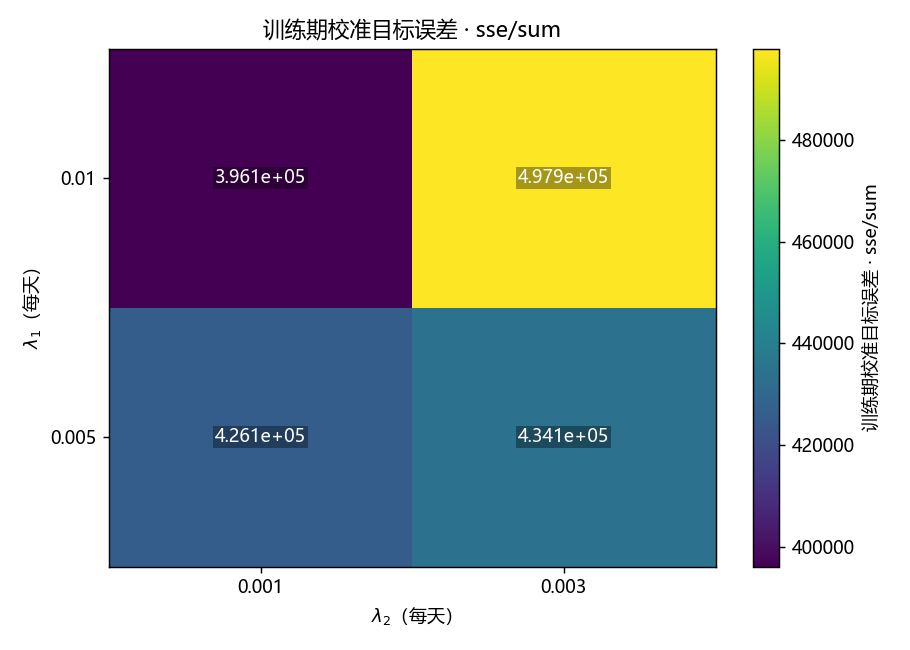

In [26]:
# 只绘已有小样本汇总；plot_type 为 error、frequency 或 weight，一次一张。
from io import BytesIO
from IPython.display import Image
import matplotlib.pyplot as plt
demo_fig,demo_ax=plot_nss_calibration_heatmap(demo_chain['summary_df'],plot_type=demo_config['plot']['plot_type'])
demo_image_buffer=BytesIO()
demo_fig.savefig(demo_image_buffer,format='png',dpi=130)
display(Image(data=demo_image_buffer.getvalue()))
plt.close(demo_fig)


## 全区间云计算入口

小样本试算通过后，显式冻结完整真实采样、日历、参数和定义，再提交一次有界 DLC 作业。云端重新执行 c01、c02 与 c03，全训练期评估网格并选择 λ，三种方法分别固定 λ 覆盖完整训练／测试序列。代码及参数在提交前冻结，云端不读取本地凭据或正式湖，不自动重试。九份产物通过本地回收、Schema／内容与全点覆盖验收后，安装到各生产单元 DemoData。运行材料归 `c03_NSSCalibration_CloudRuns/<batch>/`，与 demo 文件分开。

首版为一个 CPU 节点，进程数和点块大小显式可配。独立监控显示状态、进度、耗时与心跳；故障停止，保留云作业身份及现场。云端算法与 Notebook 导入代理共用定义。提交本身不代表计算成功，云成功也不代表本地已验收。

In [27]:
def nss_demo_artifact_specs(config):
    """九个正式 demo 的生产者、路径、局部契约与排序键。"""
    scope,parameters=config['scope'],config['input']
    range_token=f"train{scope['train']['start'].replace('-','')}-{scope['train']['end'].replace('-','')}_test{scope['test']['start'].replace('-','')}-{scope['test']['end'].replace('-','')}"
    sampling_token=f"N{parameters['N']}_{parameters['axis']}_{parameters['quantity_scope']}_{parameters['sampling_method']}_{parameters['execution_mode']}"
    numerical=config['nss'];constraints=numerical['fitting']['coefficient_constraints']
    level,short=constraints.get('level_lower_bound'),constraints.get('short_lower_bound')
    fixed=numerical['fixed_lambda'];grid=numerical['grid'];selection=numerical['selection']
    number=lambda value:format(value,'.12g').replace('e-0','e-').replace('e+0','e+')
    bound_token='endpointpositive'+number(level) if level==short and level is not None else 'level'+str(level)+'_short'+str(short)
    fixed_token=f"lambda1-{number(fixed['lambda1'])}_lambda2-{number(fixed['lambda2'])}_{bound_token}"
    calibration_token=f"g1-{number(grid['lambda1_min'])}-{number(grid['lambda1_max'])}-s{number(grid['lambda1_step'])}_g2-{number(grid['lambda2_min'])}-{number(grid['lambda2_max'])}-s{number(grid['lambda2_step'])}_{selection['error_metric'].upper()}{selection['error_aggregation']}_w{number(selection['weight_power'])}_pos{number(level)}" if level==short and level is not None else f"g1-{number(grid['lambda1_min'])}-{number(grid['lambda1_max'])}-s{number(grid['lambda1_step'])}_g2-{number(grid['lambda2_min'])}-{number(grid['lambda2_max'])}-s{number(grid['lambda2_step'])}_{selection['error_metric'].upper()}{selection['error_aggregation']}_w{number(selection['weight_power'])}_{bound_token}"
    rows=[('c01_TermStructureInputs','inputs','inputs_df',TERM_STRUCTURE_INPUT_SCHEMA,[('sample_id','ascending'),('contract_code','ascending')]),
        ('c02_NSSFitting','coefficients','fixed_coefficients',NSS_COEFFICIENT_SCHEMA,[('sample_id','ascending')]),
        ('c02_NSSFitting','fitted','fixed_fitted',NSS_FITTED_SCHEMA,[('sample_id','ascending'),('contract_code','ascending')]),
        ('c03_NSSCalibration','grid','grid_df',NSS_GRID_SCHEMA,[('grid_id','ascending')]),
        ('c03_NSSCalibration','grid_fits','grid_fits_df',NSS_GRID_FITS_SCHEMA,[('grid_id','ascending'),('sample_id','ascending')]),
        ('c03_NSSCalibration','summary','summary_df',NSS_GRID_SUMMARY_SCHEMA,[('grid_id','ascending')]),
        ('c03_NSSCalibration','selections','selections_df',NSS_SELECTION_SCHEMA,[('selection_method','ascending')]),
        ('c03_NSSCalibration','coefficients','coefficients_df',NSS_SELECTED_COEFFICIENT_SCHEMA,[('selection_method','ascending'),('sample_id','ascending')]),
        ('c03_NSSCalibration','fitted','fitted_df',NSS_SELECTED_FITTED_SCHEMA,[('selection_method','ascending'),('sample_id','ascending'),('contract_code','ascending')])]
    specs=[]
    for producer,role,key,schema,sort_keys in rows:
        prefix=f"{producer}_{scope['underlying_code']}_{range_token}_{sampling_token}_{parameters['value_col']}_delist_day_end"
        suffix='' if producer.startswith('c01') else ('_'+fixed_token+'_'+role if producer.startswith('c02') else '_'+calibration_token+'_'+role)
        relative=f'{producer}_DemoData/{prefix}{suffix}_demo.parquet'
        if len(relative.split('/')[-1])+8>255:raise ValueError('参数编码后的 demo 文件名超过 Windows 分量限制')
        specs.append(dict(producer=producer,role=role,key=key,schema=schema,sort_keys=sort_keys,relative_path=relative))
    return specs

def run_nss_cloud_demo(input_dir, output_dir, *, progress=None):
    """云端验证冻结输入，执行全链路，保存带生成身份的九份正式 demo。"""
    from pathlib import Path
    from datetime import datetime,timezone
    import hashlib,json,platform,sys
    import scipy
    import pyarrow.parquet as pq
    from a01_Methods.b02_MainContinuousAdjustment.c01_MainContinuousAdjustment import arrow_content_sha256
    from a01_Methods.b05_TermStructureModeling.c01_TermStructureInputs import (
        TERM_STRUCTURE_INPUTS_VERSION,FUTURES_CONTRACT_CALENDAR_SCHEMA,
    )
    from a01_Methods.b05_TermStructureModeling.c02_NSSFitting import NSS_FITTING_VERSION
    input_dir,output_dir=Path(input_dir),Path(output_dir)
    manifest=json.loads((input_dir/'inputs.json').read_text(encoding='utf8'))
    for name,expected in manifest['files'].items():
        if hashlib.sha256((input_dir/name).read_bytes()).hexdigest()!=expected:
            raise ValueError('冻结输入内容改变：'+name)
    config=json.loads((input_dir/'config.json').read_text(encoding='utf8'))
    sampled_table=pq.read_table(input_dir/'sampled.parquet')
    calendar_table=pq.read_table(input_dir/'calendar.parquet')
    sampled_df=sampled_table.to_pandas()
    runtime=dict(python=sys.version.split()[0],numpy=np.__version__,pandas=pd.__version__,pyarrow=pa.__version__,scipy=scipy.__version__,platform=platform.platform())
    if sys.version_info[:2]!=(3,13):raise RuntimeError('云端须使用 Python 3.13')
    for package,expected in manifest['numerical_versions'].items():
        from importlib.metadata import version
        if version(package)!=expected:raise RuntimeError('云端数值依赖与冻结配置不符：'+package)
    chain=compute_nss_demo_chain(sampled_df,calendar_table.to_pandas(),config,
        workers=config['cloud']['worker_processes'],progress=progress)
    metrics=validate_nss_demo_chain(chain,sampled_df,config)
    output_dir.mkdir(parents=True,exist_ok=True)
    chain['fixed_coefficients']=chain['fixed_result']['coefficients_df']
    chain['fixed_fitted']=chain['fixed_result']['fitted_df']
    sources=manifest['method_sources']
    upstream=manifest['upstream_demo_identity']
    output_files={};c01_identity=None
    for spec in nss_demo_artifact_specs(config):
        producer=spec['producer'];schema=spec['schema']
        table=pandas_to_arrow(chain[spec['key']],schema).sort_by(spec['sort_keys'])
        producer_relative='04_Research/a01_Methods/b05_TermStructureModeling/'+producer+'.ipynb'
        dependencies={key:sources[key] for key in ['sampling_positions','sampling_execution','main_adjustment']}
        if producer.startswith('c02') or producer.startswith('c03'):dependencies['term_structure_inputs']=sources['term_structure_inputs']
        if producer.startswith('c03'):dependencies['nss_fitting']=sources['nss_fitting']
        source_key={'c01_TermStructureInputs':'term_structure_inputs','c02_NSSFitting':'nss_fitting','c03_NSSCalibration':'nss_calibration'}[producer]
        identity=dict(artifact_role='method_demo',producer_notebook=producer_relative,
            method_version={'c01_TermStructureInputs':TERM_STRUCTURE_INPUTS_VERSION,'c02_NSSFitting':NSS_FITTING_VERSION,'c03_NSSCalibration':NSS_CALIBRATION_VERSION}[producer],
            method_source_tag='demo-dependency',method_source_sha256=sources[source_key],
            dependency_method_source_sha256=dependencies,dependency_source_sha256=manifest['dependency_sources'],
            upstream_demo_identity=upstream if producer.startswith('c01') else c01_identity,
            scope=upstream['scope'],timezone=TERM_STRUCTURE_TIMEZONE,
            parameters=dict(value_col=config['input']['value_col'],input_transform='identity',terminal_rule=TERM_STRUCTURE_TERMINAL_RULE,
                sampling=manifest['sampling_token'],sampling_reference=upstream['producer_notebook'],
                **({} if producer.startswith('c01') else dict(nss=config['nss']))),
            runtime=runtime,execution_backend='pai',output_role=spec['role'],output_rows=table.num_rows,
            output_sort_keys=spec['sort_keys'],output_schema_sha256=hashlib.sha256(schema.serialize().to_pybytes()).hexdigest(),
            output_content_sha256=arrow_content_sha256(table,schema,spec['sort_keys']))
        if producer.startswith('c01'):identity['calendar_input']=manifest['calendar_input']
        identity=json.loads(json.dumps(identity,ensure_ascii=False,allow_nan=False))
        installed_identity={**identity,'generated_at_utc':datetime.now(timezone.utc).isoformat()}
        path=output_dir/spec['relative_path'];path.parent.mkdir(parents=True,exist_ok=True)
        pq.write_table(table.replace_schema_metadata({**schema.metadata,b'demo_identity':json.dumps(installed_identity,ensure_ascii=False,sort_keys=True,allow_nan=False).encode()}),path,compression='zstd')
        if arrow_content_sha256(path,schema,spec['sort_keys'])!=identity['output_content_sha256']:
            raise ValueError('云端写入后内容复读失败')
        output_files[spec['relative_path']]=dict(sha256=hashlib.sha256(path.read_bytes()).hexdigest(),rows=table.num_rows,
            role=spec['role'],producer=producer,schema_sha256=identity['output_schema_sha256'])
        if producer.startswith('c01'):c01_identity=installed_identity
        if progress:progress(dict(phase='saving_demo',completed=len(output_files),total=9,file=spec['relative_path']))
    result=dict(status='completed',batch_id=manifest['batch_id'],input_id=manifest['input_id'],
        metrics=metrics,files=output_files,runtime=runtime)
    (output_dir/'result.json').write_text(json.dumps(result,ensure_ascii=False,indent=2,allow_nan=False)+'\n',encoding='utf8')
    return result


In [28]:
def _write_nss_cloud_json(path, value):
    """原子发布同一批次状态；仅共享替换失败作短时有界重试。"""
    import os,json,time
    from pathlib import Path
    path=Path(path);temporary=path.with_name(path.name+'.tmp')
    with temporary.open('w',encoding='utf8') as stream:
        json.dump(value,stream,ensure_ascii=False,indent=2,allow_nan=False);stream.flush();os.fsync(stream.fileno())
    for attempt in range(6):
        try:os.replace(temporary,path);return
        except OSError as error:
            if getattr(error,'winerror',None) not in (5,32) or attempt==5:raise
            time.sleep(.1*(attempt+1))

def stage_nss_cloud_demo(project_root, config, trial_report, *, batch_id):
    """试算通过后冻结完整真实输入和最小代码包；不上传、不提交。"""
    from pathlib import Path
    from importlib.metadata import version
    import re,json,hashlib,shutil
    import pyarrow.parquet as pq
    from a01_Methods.b05_TermStructureModeling.c01_TermStructureInputs import load_term_structure_demo_source
    if not re.fullmatch(r'[A-Za-z0-9][A-Za-z0-9_-]*',batch_id):raise ValueError('非法批次名')
    config_hash=hashlib.sha256(json.dumps(config,sort_keys=True).encode()).hexdigest()
    if trial_report.get('status')!='passed' or trial_report.get('data_files_written')!=0 or trial_report.get('config_sha256')!=config_hash:
        raise ValueError('必须先完成同参数、不落盘的真实试算')
    nss_demo_artifact_specs(config)
    project_root=Path(project_root)
    source=load_term_structure_demo_source(project_root,config,trial=False)
    if source['upstream_identity']['output_content_sha256']!=trial_report['upstream_content_sha256']:
        raise ValueError('试算后上游已变化，须重新试算')
    run_dir=project_root/'04_Research/a01_Methods/b05_TermStructureModeling/c03_NSSCalibration_CloudRuns'/batch_id
    run_dir.mkdir(parents=True,exist_ok=False)
    inputs_dir,code_dir=run_dir/'inputs',run_dir/'code'
    inputs_dir.mkdir();code_dir.mkdir()
    shutil.copyfile(source['upstream_path'],inputs_dir/'sampled.parquet')
    pq.write_table(source['calendar_table'],inputs_dir/'calendar.parquet',compression='zstd')
    _write_nss_cloud_json(inputs_dir/'config.json',config)
    methods=[('main_selection','b01_MainContractSelection/c01_MainContractSelection'),
        ('main_adjustment','b02_MainContinuousAdjustment/c01_MainContinuousAdjustment'),
        ('sampling_positions','b03_Sampling/c01_SamplingPositions'),('sampling_execution','b03_Sampling/c02_SamplingExecution'),
        ('term_structure_inputs','b05_TermStructureModeling/c01_TermStructureInputs'),
        ('nss_fitting','b05_TermStructureModeling/c02_NSSFitting'),('nss_calibration','b05_TermStructureModeling/c03_NSSCalibration')]
    method_sources={}
    for role,method in methods:
        for suffix in ['.py','.ipynb']:
            relative='04_Research/a01_Methods/'+method+suffix
            src,dst=project_root/relative,code_dir/relative;dst.parent.mkdir(parents=True,exist_ok=True)
            if suffix=='.py':shutil.copyfile(src,dst);continue
            book=json.loads(src.read_text(encoding='utf8'))
            native_source='\n\n'.join(''.join(c['source']) for c in book['cells'] if c['cell_type']=='code' and 'demo-dependency' in c.get('metadata',{}).get('tags',[])
                and (not role.startswith('sampling_') or 'export' in c.get('metadata',{}).get('tags',[])))
            method_sources[role]=hashlib.sha256(native_source.encode()).hexdigest()
            for cell in book['cells']:
                if cell['cell_type']!='code' or 'export' not in cell.get('metadata',{}).get('tags',[]):cell['source']=[]
                if cell['cell_type']=='code':cell['outputs']=[];cell['execution_count']=None
                cell.pop('attachments',None);cell.get('metadata',{}).pop('attachments',None)
            book['metadata']={key:value for key,value in book.get('metadata',{}).items() if key in ('kernelspec','language_info')}
            dst.write_text(json.dumps(book,ensure_ascii=False,indent=1)+'\n',encoding='utf8',newline='\n')
    dependency_sources={}
    for role,relative in [('notebook_loader','04_Research/a00_notebook_loader.py'),('data_contracts','config/data_contracts.py')]:
        dst=code_dir/relative;dst.parent.mkdir(parents=True,exist_ok=True);shutil.copyfile(project_root/relative,dst)
        dependency_sources[role]=hashlib.sha256(dst.read_bytes()).hexdigest()
    (code_dir/'config/__init__.py').write_text('',encoding='utf8')
    numerical_versions={name:version(name) for name in ['numpy','pandas','pyarrow','scipy']}
    inputs_manifest=dict(batch_id=batch_id,config_sha256=config_hash,upstream_demo_identity=source['upstream_identity'],
        upstream_path=source['upstream_path'].relative_to(project_root).as_posix(),
        calendar_input=source['calendar_input'],sampling_token=source['sampling_token'],
        dependency_sources=dependency_sources,method_sources=method_sources,numerical_versions=numerical_versions,
        files={name:hashlib.sha256((inputs_dir/name).read_bytes()).hexdigest() for name in ['sampled.parquet','calendar.parquet','config.json']})
    inputs_manifest['input_id']=hashlib.sha256(json.dumps(inputs_manifest,sort_keys=True).encode()).hexdigest()
    _write_nss_cloud_json(inputs_dir/'inputs.json',inputs_manifest)
    _write_nss_cloud_json(code_dir/'config.json',config)
    requirements=[name+'=='+version(name) for name in ['numpy','pandas','pyarrow','scipy','polars','numba','matplotlib','PyYAML']]
    (code_dir/'requirements.txt').write_text('\n'.join(requirements)+'\n',encoding='utf8',newline='\n')
    entrypoint='\n'.join([
        'from pathlib import Path','import json,os,sys,hashlib',
        "root=Path(__file__).resolve().parent",
        "manifest=json.loads((root/'code_manifest.json').read_text(encoding='utf8'))",
        "for relative,expected in manifest['files'].items():",
        "    if hashlib.sha256((root/relative).read_bytes()).hexdigest()!=expected: raise RuntimeError('frozen code changed')",
        "sys.path[:0]=[str(root),str(root/'04_Research')]",
        'from a01_Methods.b05_TermStructureModeling.c03_NSSCalibration import run_nss_cloud_demo',
        "if __name__=='__main__':",
        "    if int(os.environ.get('WORLD_SIZE','1'))!=1: raise RuntimeError('expected one DLC node')",
        "    run_nss_cloud_demo(os.environ['PAI_INPUT_RESEARCH'],os.environ['PAI_OUTPUT_MODEL'],progress=lambda event:print(json.dumps(event,ensure_ascii=False),flush=True))",''])
    (code_dir/'entrypoint.py').write_text(entrypoint,encoding='utf8',newline='\n')
    code_files={path.relative_to(code_dir).as_posix():hashlib.sha256(path.read_bytes()).hexdigest() for path in code_dir.rglob('*') if path.is_file()}
    _write_nss_cloud_json(code_dir/'code_manifest.json',dict(files=code_files,code_id=hashlib.sha256(json.dumps(code_files,sort_keys=True).encode()).hexdigest()))
    _write_nss_cloud_json(run_dir/'trial_report.json',trial_report)
    _write_nss_cloud_json(run_dir/'submission.json',dict(state='staged',batch_id=batch_id,input_id=inputs_manifest['input_id']))
    return run_dir

def create_nss_pai_session(config):
    """当前进程显式 PUBLIC 默认会话；凭据由本机既有链提供。"""
    from pai.session import setup_default_session
    from alibabacloud_tea_util.models import RuntimeOptions
    resource=config['cloud']
    return setup_default_session(region_id=resource['region'],workspace_id=resource['workspace_id'],
        oss_bucket_name=resource['bucket_name'],network='PUBLIC',oss_endpoint=f"oss-{resource['region']}.aliyuncs.com",
        runtime=RuntimeOptions(autoretry=False,max_attempts=1,connect_timeout=5000,read_timeout=10000))

def submit_nss_cloud_demo(run_dir, *, session):
    """上传本批冻结输入，提交唯一 DLC 作业并立即记录 ID，不自动重试。"""
    from pathlib import Path
    import json,hashlib
    from pai.estimator import Estimator
    run_dir=Path(run_dir);code_dir=run_dir/'code';inputs_dir=run_dir/'inputs'
    record=json.loads((run_dir/'submission.json').read_text(encoding='utf8'))
    if record['state']!='staged':raise RuntimeError('本批已进入提交，禁止重复创建作业')
    config=json.loads((code_dir/'config.json').read_text(encoding='utf8'));resource=config['cloud']
    code_manifest=json.loads((code_dir/'code_manifest.json').read_text(encoding='utf8'))
    for relative,expected in code_manifest['files'].items():
        if hashlib.sha256((code_dir/relative).read_bytes()).hexdigest()!=expected:raise ValueError('冻结代码或参数变化')
    bucket=session.oss_bucket
    if bucket.bucket_name!=resource['bucket_name']:raise ValueError('OSS bucket 不匹配')
    prefix='research/nss_demo/'+record['input_id']+'/'+record['batch_id']+'/'
    try:
        for name in ['sampled.parquet','calendar.parquet','config.json','inputs.json']:
            bucket.put_object_from_file(prefix+'inputs/'+name,str(inputs_dir/name))
            expected=hashlib.sha256((inputs_dir/name).read_bytes()).hexdigest()
            if hashlib.sha256(bucket.get_object(prefix+'inputs/'+name).read()).hexdigest()!=expected:raise ValueError('远端输入内容不一致')
        record.update(state='submitting',oss_prefix=prefix,output_uri=f'oss://{bucket.bucket_name}/{prefix}outputs/',
            display_name='latitude-nss-'+record['batch_id'])
        _write_nss_cloud_json(run_dir/'submission.json',record)
        estimator=Estimator(image_uri=resource['image_uri'],command='python entrypoint.py',source_dir=str(code_dir),
            job_type='PyTorchJob',instance_type=resource['instance_type'],instance_count=1,
            requirements=(code_dir/'requirements.txt').read_text(encoding='utf8').splitlines(),
            environments={'OMP_NUM_THREADS':'1','OPENBLAS_NUM_THREADS':'1','MKL_NUM_THREADS':'1','NUMEXPR_NUM_THREADS':'1'},
            max_run_time=resource['max_run_time'],base_job_name='latitude-nss-'+record['batch_id'],output_path=record['output_uri'],session=session)
        job=estimator.fit(inputs={'research':f'oss://{bucket.bucket_name}/{prefix}inputs/'},wait=False,
            show_logs=False,job_name=record['display_name'])
        record.update(state='submitted',job_id=job.id,console_url=job.console_uri)
        _write_nss_cloud_json(run_dir/'submission.json',record)
        return record
    except BaseException as error:
        record.update(state='submission_uncertain' if record['state']=='submitting' else 'submission_failed',error=f'{type(error).__name__}: {error}')
        _write_nss_cloud_json(run_dir/'submission.json',record);raise

def query_nss_cloud_demo(run_dir, *, session):
    """一次读取作业状态；云成功先标待回收，不冒充 demo 完成。"""
    from pathlib import Path
    import json
    from pai.job import TrainingJob,TrainingJobStatus
    run_dir=Path(run_dir);record=json.loads((run_dir/'submission.json').read_text(encoding='utf8'))
    if record['state']=='recovered':return record
    if not record.get('job_id'):raise RuntimeError('没有确认的 DLC job ID，禁止猜测任务身份')
    job=TrainingJob.get(record['job_id'],session=session)
    record['cloud_status']=job.status
    if record.get('display_name') and job.training_job_name!=record['display_name']:
        raise RuntimeError('DLC 作业名称与本批不符')
    if job.status==TrainingJobStatus.Succeed:
        record.update(state='cloud_completed_pending_recovery',actual_output_uri=job.output_path('model'))
    elif job.status in {*TrainingJobStatus.completed_status(),TrainingJobStatus.CreateFailed}:
        record.update(state='cloud_failed',error=job.reason_message)
    else:record['state']='running'
    _write_nss_cloud_json(run_dir/'submission.json',record)
    return record

def stop_nss_cloud_demo(run_dir, *, session):
    """仅停止本批确认 ID 或唯一精确名称所属的活动作业，保留现场。"""
    from pathlib import Path
    import json
    from pai.job import TrainingJobStatus
    run_dir=Path(run_dir)
    record=json.loads((run_dir/'submission.json').read_text(encoding='utf8'))
    job_id=record.get('job_id')
    display_name=record.get('display_name')
    if not job_id and display_name and record['state'] in ('submitting','submission_uncertain'):
        page=session.job_api.list(display_name=display_name,page_size=50)
        exact=[item for item in page.items if item.get('DisplayName')==display_name]
        _write_nss_cloud_json(run_dir/'submission_reconciliation.json',dict(display_name=display_name,
            exact_matches=[item.get('JobId') for item in exact]))
        if len(exact)>1:raise RuntimeError('本批唯一作业名对应多个 ID，须人工核查')
        if exact:
            job_id=exact[0]['JobId'];record['job_id']=job_id
            _write_nss_cloud_json(run_dir/'submission.json',record)
    if not job_id:
        result=dict(no_confirmed_job=True,submission_state=record['state'])
    else:
        actual=session.job_api.get(job_id)
        if actual.get('DisplayName')!=display_name:raise RuntimeError('云作业不属于本批，拒绝停止')
        terminal={*TrainingJobStatus.completed_status(),TrainingJobStatus.CreateFailed}
        requested=actual['Status'] not in terminal
        if requested:session.job_api.stop(job_id)
        result=dict(job_id=job_id,stop_requested=requested,status=session.job_api.get(job_id)['Status'] if requested else actual['Status'])
    _write_nss_cloud_json(run_dir/'cloud_stop.json',result)
    return result

def recover_nss_cloud_demo(run_dir, project_root, *, session):
    """本地下载、复读和全点验证后安装九份 demo。任何失败保留现场。"""
    from pathlib import Path
    from urllib.parse import urlparse
    import json,hashlib,os,shutil
    import pyarrow.parquet as pq
    from a01_Methods.b02_MainContinuousAdjustment.c01_MainContinuousAdjustment import arrow_content_sha256
    run_dir,project_root=Path(run_dir),Path(project_root)
    record=query_nss_cloud_demo(run_dir,session=session)
    if record['state']=='recovered':return record
    if record['state']!='cloud_completed_pending_recovery':raise RuntimeError('云端未成功，不能安装 demo')
    uri=urlparse(record['actual_output_uri']);bucket=session.oss_bucket
    if uri.scheme!='oss' or uri.netloc!=bucket.bucket_name or not uri.path.lstrip('/').startswith(record['oss_prefix']+'outputs/'):
        raise ValueError('输出路径不属于本批作业')
    prefix=uri.path.lstrip('/').rstrip('/')+'/'
    download_dir=run_dir/'download';download_dir.mkdir(exist_ok=False)
    try:
        bucket.get_object_to_file(prefix+'result.json',str(download_dir/'result.json'))
        result=json.loads((download_dir/'result.json').read_text(encoding='utf8'))
        inputs_manifest=json.loads((run_dir/'inputs/inputs.json').read_text(encoding='utf8'))
        config=json.loads((run_dir/'inputs/config.json').read_text(encoding='utf8'))
        # 只安装当前方法与依赖仍匹配的冻结批次；并行编辑不能静默装入旧结果。
        current_config=project_root/'04_Research/a01_Methods/b05_TermStructureModeling/c03_NSSCalibration.yaml'
        from a01_Methods.b05_TermStructureModeling.c01_TermStructureInputs import load_nss_demo_config
        if load_nss_demo_config(current_config)!=config:raise ValueError('当前参数已变化，停止安装冻结批次结果')
        for role,expected in inputs_manifest['method_sources'].items():
            paths={'main_selection':'b01_MainContractSelection/c01_MainContractSelection','main_adjustment':'b02_MainContinuousAdjustment/c01_MainContinuousAdjustment',
                'sampling_positions':'b03_Sampling/c01_SamplingPositions','sampling_execution':'b03_Sampling/c02_SamplingExecution',
                'term_structure_inputs':'b05_TermStructureModeling/c01_TermStructureInputs','nss_fitting':'b05_TermStructureModeling/c02_NSSFitting','nss_calibration':'b05_TermStructureModeling/c03_NSSCalibration'}
            book=json.loads((project_root/'04_Research/a01_Methods'/(paths[role]+'.ipynb')).read_text(encoding='utf8'))
            source='\n\n'.join(''.join(c['source']) for c in book['cells'] if c['cell_type']=='code' and 'demo-dependency' in c.get('metadata',{}).get('tags',[])
                and (not role.startswith('sampling_') or 'export' in c.get('metadata',{}).get('tags',[])))
            if hashlib.sha256(source.encode()).hexdigest()!=expected:raise ValueError('当前定义已变化：'+role)
        for role,relative in [('notebook_loader','04_Research/a00_notebook_loader.py'),('data_contracts','config/data_contracts.py')]:
            if hashlib.sha256((project_root/relative).read_bytes()).hexdigest()!=inputs_manifest['dependency_sources'][role]:raise ValueError('当前依赖已变化：'+role)
        if result['status']!='completed' or result['batch_id']!=record['batch_id'] or result['input_id']!=record['input_id']:
            raise ValueError('云端结果身份或状态不一致')
        specs=nss_demo_artifact_specs(config)
        if set(result['files'])!={spec['relative_path'] for spec in specs}:raise ValueError('九份 demo 文件集合不完整')
        tables={}
        for spec in specs:
            relative=spec['relative_path'];path=download_dir/relative;path.parent.mkdir(parents=True,exist_ok=True)
            bucket.get_object_to_file(prefix+relative,str(path))
            if hashlib.sha256(path.read_bytes()).hexdigest()!=result['files'][relative]['sha256']:raise ValueError('下载文件摘要不一致')
            table=pq.read_table(path);schema=spec['schema'];identity=json.loads(table.schema.metadata[b'demo_identity'])
            native_schema=table.schema.with_metadata({k:v for k,v in table.schema.metadata.items() if k!=b'demo_identity'})
            if not native_schema.equals(schema,check_metadata=True) or table.num_rows!=result['files'][relative]['rows']:raise ValueError('结果 Schema／行数不一致')
            if identity['execution_backend']!='pai' or identity['scope']!=inputs_manifest['upstream_demo_identity']['scope']:raise ValueError('结果执行来源／范围不一致')
            key={'c01_TermStructureInputs':'term_structure_inputs','c02_NSSFitting':'nss_fitting','c03_NSSCalibration':'nss_calibration'}[spec['producer']]
            if identity['method_source_sha256']!=inputs_manifest['method_sources'][key]:raise ValueError('结果代码身份不一致')
            if arrow_content_sha256(table,schema,spec['sort_keys'])!=identity['output_content_sha256']:raise ValueError('结果内容摘要不一致')
            tables[spec['key']]=table.to_pandas()
        chain={**tables,'fixed_result':{'coefficients_df':tables['fixed_coefficients'],'fitted_df':tables['fixed_fitted']}}
        sampled_df=pq.read_table(run_dir/'inputs/sampled.parquet').to_pandas()
        metrics=validate_nss_demo_chain(chain,sampled_df,config)
        if metrics!=result['metrics']:raise ValueError('云端汇总与本地全点验收不一致')
        # 先完成全部文件验收，再安装；备份只归本批，不删除历史成果。
        installed=[];backup_dir=run_dir/'replaced_files'
        try:
            for spec in specs:
                relative=spec['relative_path'];src=download_dir/relative
                dst=project_root/'04_Research/a01_Methods/b05_TermStructureModeling'/relative
                dst.parent.mkdir(parents=True,exist_ok=True)
                if dst.exists():
                    old_table=pq.read_table(dst);old_identity=json.loads(old_table.schema.metadata[b'demo_identity'])
                    new_table=pq.read_table(src);new_identity=json.loads(new_table.schema.metadata[b'demo_identity'])
                    old_schema=old_table.schema.with_metadata({k:v for k,v in old_table.schema.metadata.items() if k!=b'demo_identity'})
                    if arrow_content_sha256(old_table,old_schema,old_identity['output_sort_keys'])!=old_identity['output_content_sha256']:raise ValueError('已有 demo 损坏，停止安装')
                    if {k:v for k,v in old_identity.items() if k!='generated_at_utc'}=={k:v for k,v in new_identity.items() if k!='generated_at_utc'}:
                        continue
                    backup=backup_dir/relative;backup.parent.mkdir(parents=True,exist_ok=True);shutil.copyfile(dst,backup)
                else:backup=None
                staging=dst.with_name(dst.name+'.staging')
                if staging.exists():raise RuntimeError('存在未处理安装 staging')
                shutil.copyfile(src,staging);os.replace(staging,dst);installed.append((dst,backup))
                if hashlib.sha256(dst.read_bytes()).hexdigest()!=result['files'][relative]['sha256']:raise ValueError('安装后字节摘要不一致')
        except BaseException:
            for dst,backup in reversed(installed):
                if backup is not None:shutil.copyfile(backup,dst)
                else:
                    failed_install=run_dir/'failed_install'/dst.parent.name/dst.name
                    failed_install.parent.mkdir(parents=True,exist_ok=True);os.replace(dst,failed_install)
            raise
        record.update(state='recovered',metrics=metrics,installed_files=[spec['relative_path'] for spec in specs])
        _write_nss_cloud_json(run_dir/'submission.json',record)
        return record
    except BaseException as error:
        record.update(state='recovery_failed',error=f'{type(error).__name__}: {error}')
        _write_nss_cloud_json(run_dir/'submission.json',record);raise


In [29]:
# 以下入口仅定义操作；默认 Notebook 不上传或提交。
# 试算通过后由明确有界的云执行工具调用：
# run_dir=stage_nss_cloud_demo(candidate_root,demo_config,demo_trial_report,batch_id='明确新批次名')
# session=create_nss_pai_session(demo_config)
# submit_nss_cloud_demo(run_dir,session=session)
# query_nss_cloud_demo(run_dir,session=session)
# recover_nss_cloud_demo(run_dir,candidate_root,session=session)
